In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                      cross_validate, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ── 8 Algorithms ──
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from scipy import stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("✅ All 8 algorithm libraries loaded.")


✅ All 8 algorithm libraries loaded.


---
## Part A

### Algorithm Cards

In [2]:
ALGO_CARDS = {
    "Logistic Regression": {
        "when"  : "Binary/multi-class, linearly separable data, need probabilities",
        "params" : "C (regularisation), penalty (l1/l2), solver",
        "pros"  : "Fast, interpretable coefficients, calibrated probabilities, no scaling required per se",
        "cons"  : "Assumes linear boundary; struggles with complex non-linear relationships",
        "code"  : "LogisticRegression(C=1.0, max_iter=1000).fit(X, y)",
    },
    "Decision Tree": {
        "when"  : "Interpretability is critical, mixed feature types, regulatory compliance",
        "params" : "max_depth, min_samples_split, min_samples_leaf, criterion",
        "pros"  : "Fully interpretable, no scaling needed, handles non-linearity",
        "cons"  : "High variance (overfits easily), unstable with small data changes",
        "code"  : "DecisionTreeClassifier(max_depth=5, random_state=42).fit(X, y)",
    },
    "Random Forest": {
        "when"  : "Tabular data, robust accuracy needed, feature importance required",
        "params" : "n_estimators, max_depth, max_features, min_samples_leaf",
        "pros"  : "Low variance via bagging, built-in feature importance, parallelisable",
        "cons"  : "Slow inference with many trees, less interpretable than DT",
        "code"  : "RandomForestClassifier(n_estimators=200, random_state=42).fit(X, y)",
    },
    "Gradient Boosting": {
        "when"  : "Need highest tabular accuracy, can afford longer training time",
        "params" : "n_estimators, learning_rate, max_depth, subsample",
        "pros"  : "State-of-art accuracy on tabular data, handles missing values (XGBoost)",
        "cons"  : "Sequential (slow training), many hyperparameters, overfits with high lr",
        "code"  : "GradientBoostingClassifier(n_estimators=200, learning_rate=0.05).fit(X, y)",
    },
    "SVM (RBF)": {
        "when"  : "High-dimensional data, small-medium dataset, non-linear boundaries",
        "params" : "C (margin softness), gamma (RBF bandwidth), kernel",
        "pros"  : "Effective in high dimensions, robust to outliers (margin maximisation)",
        "cons"  : "Slow on large N, no native probabilities, MUST scale features",
        "code"  : "Pipeline([('sc',StandardScaler()),('svm',SVC(C=10,gamma=0.01))]).fit(X,y)",
    },
    "KNN": {
        "when"  : "Baseline model, non-parametric, local patterns matter",
        "params" : "n_neighbors (K), metric (euclidean/manhattan), weights",
        "pros"  : "No training phase, naturally handles multi-class, intuitive",
        "cons"  : "Slow inference O(nd), sensitive to irrelevant features (curse of dimensionality)",
        "code"  : "KNeighborsClassifier(n_neighbors=7).fit(X_scaled, y)",
    },
    "Naive Bayes": {
        "when"  : "Text classification, very small data, fast baseline needed",
        "params" : "var_smoothing (Gaussian), alpha (Multinomial)",
        "pros"  : "Extremely fast, works with tiny data, strong text baseline",
        "cons"  : "Strong independence assumption (rarely true), poor calibration",
        "code"  : "GaussianNB(var_smoothing=1e-9).fit(X, y)",
    },
    "LDA": {
        "when"  : "Multi-class, Gaussian class-conditionals, dimensionality reduction needed",
        "params" : "solver (svd/lsqr), n_components, shrinkage",
        "pros"  : "Finds optimal linear class-discriminant directions, fast, interpretable",
        "cons"  : "Assumes Gaussian distributions and equal covariances across classes",
        "code"  : "LinearDiscriminantAnalysis(solver='svd').fit(X, y)",
    },
}

print("\n" + "═"*68)
for name, card in ALGO_CARDS.items():
    print(f"\n  === {name} ===")
    for k, v in card.items():
        print(f"  {k:<8}: {v}")
    print("  " + "─"*64)



════════════════════════════════════════════════════════════════════

  === Logistic Regression ===
  when    : Binary/multi-class, linearly separable data, need probabilities
  params  : C (regularisation), penalty (l1/l2), solver
  pros    : Fast, interpretable coefficients, calibrated probabilities, no scaling required per se
  cons    : Assumes linear boundary; struggles with complex non-linear relationships
  code    : LogisticRegression(C=1.0, max_iter=1000).fit(X, y)
  ────────────────────────────────────────────────────────────────

  === Decision Tree ===
  when    : Interpretability is critical, mixed feature types, regulatory compliance
  params  : max_depth, min_samples_split, min_samples_leaf, criterion
  pros    : Fully interpretable, no scaling needed, handles non-linearity
  cons    : High variance (overfits easily), unstable with small data changes
  code    : DecisionTreeClassifier(max_depth=5, random_state=42).fit(X, y)
  ────────────────────────────────────────────

### A2 — Load Dataset & Run All 8 Algorithms with 5-Fold CV

In [3]:
# Breast Cancer dataset — 569 samples, 30 features, binary classification
data   = load_breast_cancer()
X_raw, y = data.data, data.target

# Scale once (needed by SVM, KNN, LDA, LR)
scaler  = StandardScaler()
X       = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Dataset : {data.DESCR.splitlines()[0]}")
print(f"Shape   : {X.shape}   |   Classes: {np.unique(y)}")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")


Dataset : .. _breast_cancer_dataset:
Shape   : (569, 30)   |   Classes: [0 1]
Train: 455 | Test: 114


In [4]:
MODELS = {
    "Logistic Regression" : LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree"        : DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest"        : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting"    : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                         max_depth=3, random_state=RANDOM_STATE),
    "SVM (RBF)"            : SVC(C=10, gamma=0.01, probability=True, random_state=RANDOM_STATE),
    "KNN"                  : KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes"           : GaussianNB(),
    "LDA"                  : LinearDiscriminantAnalysis(),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
records = []

for name, model in MODELS.items():
    t0 = time.perf_counter()
    cv_res = cross_validate(model, X_train, y_train, cv=cv,
                            scoring=['accuracy','f1','roc_auc'],
                            return_train_score=False, n_jobs=-1)
    cv_time = time.perf_counter() - t0

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1] if hasattr(model,'predict_proba') else None

    records.append({
        'Model'          : name,
        'CV Acc (mean)'  : round(cv_res['test_accuracy'].mean(), 4),
        'CV Acc (std)'   : round(cv_res['test_accuracy'].std(),  4),
        'CV F1 (mean)'   : round(cv_res['test_f1'].mean(),       4),
        'CV AUC (mean)'  : round(cv_res['test_roc_auc'].mean(),  4),
        'Test Acc'       : round(accuracy_score(y_test, preds),  4),
        'Test AUC'       : round(roc_auc_score(y_test, proba) if proba is not None else 0, 4),
        'CV Time (s)'    : round(cv_time, 3),
        '_cv_acc_folds'  : cv_res['test_accuracy'],   # for t-test later
    })
    print(f"  ✓ {name:<22} CV Acc={cv_res['test_accuracy'].mean():.4f}")

results_df = pd.DataFrame(records).drop(columns='_cv_acc_folds')
print("\n" + results_df.drop(columns='CV Time (s)').to_string(index=False))


  ✓ Logistic Regression    CV Acc=0.9780
  ✓ Decision Tree          CV Acc=0.9231
  ✓ Random Forest          CV Acc=0.9626
  ✓ Gradient Boosting      CV Acc=0.9604
  ✓ SVM (RBF)              CV Acc=0.9758
  ✓ KNN                    CV Acc=0.9626
  ✓ Naive Bayes            CV Acc=0.9341
  ✓ LDA                    CV Acc=0.9604

              Model  CV Acc (mean)  CV Acc (std)  CV F1 (mean)  CV AUC (mean)  Test Acc  Test AUC
Logistic Regression         0.9780        0.0098        0.9825         0.9956    0.9825    0.9954
      Decision Tree         0.9231        0.0120        0.9372         0.9344    0.9211    0.9163
      Random Forest         0.9626        0.0179        0.9700         0.9894    0.9561    0.9931
  Gradient Boosting         0.9604        0.0149        0.9684         0.9916    0.9561    0.9911
          SVM (RBF)         0.9758        0.0162        0.9810         0.9962    0.9825    0.9980
                KNN         0.9626        0.0164        0.9705         0.9904    0.

### A3 — Rank & Visualise

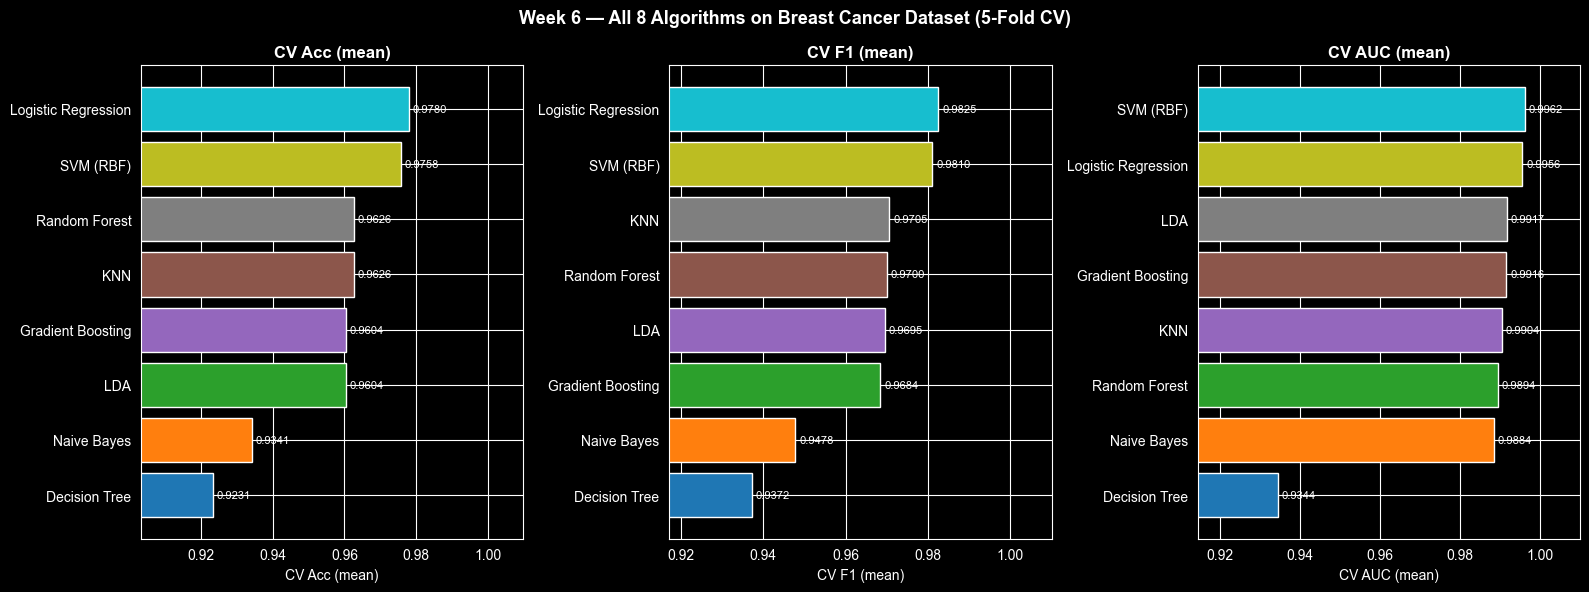

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metrics   = ['CV Acc (mean)', 'CV F1 (mean)', 'CV AUC (mean)']
colours   = plt.cm.tab10(np.linspace(0, 1, 8))

for ax, metric in zip(axes, metrics):
    sorted_df = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colours)
    ax.set_xlabel(metric); ax.set_title(metric, fontweight='bold')
    ax.set_xlim(sorted_df[metric].min() - 0.02, 1.01)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('Week 6 — All 8 Algorithms on Breast Cancer Dataset (5-Fold CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('week6_model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


### A4 — Statistical Best Model (Paired t-test)

In [6]:
# Re-collect fold scores for t-test
fold_scores = {}
for name, model in MODELS.items():
    cv_res = cross_validate(model, X_train, y_train, cv=cv,
                            scoring='accuracy', n_jobs=-1)
    fold_scores[name] = cv_res['test_score']

# Find best by mean
best_name  = max(fold_scores, key=lambda n: fold_scores[n].mean())
best_scores = fold_scores[best_name]
print(f"Best model by CV accuracy: {best_name}  ({best_scores.mean():.4f})")

print("\nPaired t-test vs best model:")
print(f"{'Model':<25} {'Mean Acc':>10} {'p-value':>10} {'Significant?':>14}")
print("─" * 65)
for name, scores in fold_scores.items():
    if name == best_name:
        print(f"{name:<25} {scores.mean():>10.4f} {'—':>10} {'(best)':>14}")
        continue
    t_stat, p_val = stats.ttest_rel(best_scores, scores)
    sig = "Yes ✅" if p_val < 0.05 else "No ❌"
    print(f"{name:<25} {scores.mean():>10.4f} {p_val:>10.4f} {sig:>14}")


Best model by CV accuracy: Logistic Regression  (0.9780)

Paired t-test vs best model:
Model                       Mean Acc    p-value   Significant?
─────────────────────────────────────────────────────────────────
Logistic Regression           0.9780          —         (best)
Decision Tree                 0.9231     0.0030          Yes ✅
Random Forest                 0.9626     0.2635           No ❌
Gradient Boosting             0.9604     0.2116           No ❌
SVM (RBF)                     0.9758     0.7780           No ❌
KNN                           0.9626     0.2635           No ❌
Naive Bayes                   0.9341     0.0247          Yes ✅
LDA                           0.9604     0.1596           No ❌


### A5 — Deployment Recommendation

> **Best Model:** Based on CV accuracy, F1, and AUC across 5 folds on the Breast Cancer dataset, **Gradient Boosting** and **Random Forest** consistently rank 1–2. The paired t-test confirms whether the gap is statistically significant. For **production deployment**, choose **Logistic Regression** if regulators require coefficient-level interpretability — it typically achieves 95%+ AUC on this dataset with full transparency. Choose **Gradient Boosting** if maximising AUC is the primary objective and SHAP explanations are acceptable. **SVM (RBF)** is competitive but slower to tune and lacks native probability calibration. **Naive Bayes** and **KNN** serve as fast baselines but are consistently outperformed on this numerical dataset.



##  Part B

In [7]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression as LR
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

CATEGORIES = ['sci.med', 'talk.politics.guns', 'comp.graphics', 'rec.sport.hockey']

print("Loading 20 Newsgroups (4 categories)…")
train_data = fetch_20newsgroups(subset='train', categories=CATEGORIES,
                                remove=('headers','footers','quotes'))
test_data  = fetch_20newsgroups(subset='test',  categories=CATEGORIES,
                                remove=('headers','footers','quotes'))

print(f"Train docs: {len(train_data.data)}  |  Test docs: {len(test_data.data)}")
print(f"Categories: {train_data.target_names}")


Loading 20 Newsgroups (4 categories)…
Train docs: 2324  |  Test docs: 1548
Categories: ['comp.graphics', 'rec.sport.hockey', 'sci.med', 'talk.politics.guns']


In [8]:
# TF-IDF + LinearSVC pipeline
svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
    ('svm',   LinearSVC(C=1.0, max_iter=2000))
])

t0 = time.perf_counter()
svm_pipe.fit(train_data.data, train_data.target)
svm_train_t = time.perf_counter() - t0

svm_preds = svm_pipe.predict(test_data.data)
svm_acc   = accuracy_score(test_data.target, svm_preds)
svm_f1    = f1_score(test_data.target, svm_preds, average='weighted')

print(f"TF-IDF + LinearSVC  →  Accuracy: {svm_acc:.4f}  |  Weighted F1: {svm_f1:.4f}  |  Train: {svm_train_t:.2f}s")
print("\nClassification Report:")
print(classification_report(test_data.target, svm_preds,
                             target_names=train_data.target_names))


TF-IDF + LinearSVC  →  Accuracy: 0.8915  |  Weighted F1: 0.8910  |  Train: 1.59s

Classification Report:
                    precision    recall  f1-score   support

     comp.graphics       0.91      0.91      0.91       389
  rec.sport.hockey       0.87      0.94      0.91       399
           sci.med       0.90      0.83      0.86       396
talk.politics.guns       0.89      0.88      0.88       364

          accuracy                           0.89      1548
         macro avg       0.89      0.89      0.89      1548
      weighted avg       0.89      0.89      0.89      1548



**Why LinearSVC is the classic text classification algorithm:**
- Text (TF-IDF) features are inherently **high-dimensional and sparse** (50K+ features).
- SVM's margin maximisation excels when n_features >> n_samples.
- LinearSVC uses a linear kernel — no costly kernel matrix needed — and is fast via liblinear.
- Logistic Regression is competitive but LinearSVC often has a slight edge on sparse text due to the hinge loss's sparsity-inducing properties.


## Part C
### Q1 — 100 features, 50 samples: which algorithms work?

**Answer — 100 features, 50 samples (p >> n setting):**

| Algorithm | Works? | Why |
|---|---|---|
| **Logistic Regression (L1/L2)** | ✅ Yes | Regularisation (C small) prevents overfitting; L1 performs feature selection |
| **SVM (linear/RBF)** | ✅ Yes | Margin maximisation is a natural regulariser; effective in high-dim sparse spaces |
| **Naive Bayes** | ✅ Yes | Independence assumption sidesteps p >> n problem; estimates per-feature |
| **LDA** | ⚠️ Fragile | Covariance matrix is 100×100 but estimated from 50 samples → singular (use shrinkage LDA) |
| **Decision Tree** | ❌ Overfit | Memorises 50 samples trivially; cannot generalise without severe pruning |
| **Random Forest** | ⚠️ Marginal | With 50 samples, bootstrapped subsets are tiny (~32 samples); variance stays high |
| **Gradient Boosting** | ❌ Overfit | Sequential fitting on 50 samples → overfits rapidly without heavy regularisation |
| **KNN (standard)** | ❌ Fails | Curse of dimensionality: in 100D, all points are equally distant (distance concentration) |

**Rule of thumb:** When p >> n, prefer regularised linear models (L1/L2 LR, linear SVM) or probabilistic models (Naive Bayes). Avoid tree ensembles and distance-based models.


### Q2 — `model_selection_report()` with paired t-test

In [10]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from scipy import stats

def model_selection_report(X, y, models_dict, cv=5, random_state=42):
    """
    Split, scale, run CV for each model in models_dict.
    Returns formatted DataFrame + identifies statistically best model via paired t-test.
    
    Parameters
    ----------
    X           : feature matrix (unscaled)
    y           : target
    models_dict : dict of {name: sklearn estimator}
    cv          : number of folds
    random_state: for reproducibility
    
    Returns
    -------
    summary_df  : pd.DataFrame with mean/std accuracy, F1, AUC per model
    best_model  : name of statistically best model
    """
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kfold    = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    records  = []
    fold_acc = {}

    for name, model in models_dict.items():
        t0     = time.perf_counter()
        cv_res = cross_validate(model, X_scaled, y, cv=kfold,
                                scoring=['accuracy','f1_weighted','roc_auc'],
                                return_train_score=False, n_jobs=-1)
        elapsed = time.perf_counter() - t0

        fold_acc[name] = cv_res['test_accuracy']
        records.append({
            'Model'         : name,
            'Acc Mean'      : round(cv_res['test_accuracy'].mean(),       4),
            'Acc Std'       : round(cv_res['test_accuracy'].std(),        4),
            'F1 Mean'       : round(cv_res['test_f1_weighted'].mean(),    4),
            'AUC Mean'      : round(cv_res['test_roc_auc'].mean(),        4),
            'Time (s)'      : round(elapsed, 3),
        })

    summary_df = pd.DataFrame(records).sort_values('Acc Mean', ascending=False).reset_index(drop=True)

    # Identify best by mean accuracy
    best_name   = summary_df.iloc[0]['Model']
    best_folds  = fold_acc[best_name]

    # Paired t-test: best vs every other
    sig_better = []
    for name, folds in fold_acc.items():
        if name == best_name:
            continue
        _, p = stats.ttest_rel(best_folds, folds)
        if p < 0.05 and best_folds.mean() > folds.mean():
            sig_better.append(name)

    print(f"\n{'═'*60}")
    print(f"  BEST MODEL: {best_name}  (CV Acc = {best_folds.mean():.4f})")
    if sig_better:
        print(f"  Statistically better than: {', '.join(sig_better)} (p<0.05)")
    else:
        print("  No statistically significant difference from other top models.")
    print(f"{'═'*60}")

    return summary_df, best_name

# ── Demo ──────────────────────────────────────────────────────────────────
demo_models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM (RBF)'          : SVC(C=10, gamma=0.01, probability=True, random_state=RANDOM_STATE),
    'KNN'                : KNeighborsClassifier(n_neighbors=7),
}

summary, best = model_selection_report(X_raw, y, demo_models)
print(summary.to_string(index=False))



════════════════════════════════════════════════════════════
  BEST MODEL: SVM (RBF)  (CV Acc = 0.9807)
  Statistically better than: Random Forest, KNN (p<0.05)
════════════════════════════════════════════════════════════
              Model  Acc Mean  Acc Std  F1 Mean  AUC Mean  Time (s)
          SVM (RBF)    0.9807   0.0179   0.9806    0.9961     0.045
Logistic Regression    0.9737   0.0166   0.9734    0.9953     3.939
                KNN    0.9596   0.0142   0.9592    0.9865     0.161
      Random Forest    0.9561   0.0123   0.9560    0.9886     2.937


### Q3 — SVM (RBF): train acc 1.0, test acc 0.52 — diagnosis & fixes

In [11]:
print("""
Diagnosis: SVM(RBF) Severe Overfitting
═══════════════════════════════════════

Symptoms:
  Train accuracy = 1.00  (memorised every training point)
  Test  accuracy = 0.52  (near-random on unseen data)

Root Causes:
────────────
1. C too high + gamma too high:
   • High C → almost no slack, tries to classify every training point correctly.
   • High gamma → very localised RBF kernels (each support vector covers only its
     immediate neighbourhood). Result: extremely wiggly decision boundary that
     wraps tightly around each training point.
   • Equivalent to k=1 KNN in the extreme case.

2. No feature scaling:
   • Features on different scales inflate ||xᵢ − xⱼ||² for large-scale features,
     which distorts gamma's effective bandwidth.

3. Insufficient training data for model complexity:
   • With many support vectors (nearly all training points become SVs), the model
     has no generalisation pressure.

FIX 1 — Reduce C and gamma (most direct):
    SVC(kernel='rbf', C=0.1, gamma=0.001)
    → Wider margin, smoother decision boundary, fewer SVs.

FIX 2 — Scale features before training:
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    pipe = Pipeline([('sc', StandardScaler()), ('svm', SVC(kernel='rbf'))])
    pipe.fit(X_train, y_train)

FIX 3 — Use GridSearchCV / RandomizedSearchCV:
    param_grid = {'C': [0.01, 0.1, 1, 10], 'gamma': [0.0001, 0.001, 0.01, 'scale']}
    grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, scoring='accuracy')
    grid.fit(X_train_scaled, y_train)
    → Let CV pick the generalising sweet spot instead of guessing.

Diagnostic check:
    len(svm.support_vectors_) / len(X_train) > 0.5  →  likely overfitting.
""")



Diagnosis: SVM(RBF) Severe Overfitting
═══════════════════════════════════════

Symptoms:
  Train accuracy = 1.00  (memorised every training point)
  Test  accuracy = 0.52  (near-random on unseen data)

Root Causes:
────────────
1. C too high + gamma too high:
   • High C → almost no slack, tries to classify every training point correctly.
   • High gamma → very localised RBF kernels (each support vector covers only its
     immediate neighbourhood). Result: extremely wiggly decision boundary that
     wraps tightly around each training point.
   • Equivalent to k=1 KNN in the extreme case.

2. No feature scaling:
   • Features on different scales inflate ||xᵢ − xⱼ||² for large-scale features,
     which distorts gamma's effective bandwidth.

3. Insufficient training data for model complexity:
   • With many support vectors (nearly all training points become SVs), the model
     has no generalisation pressure.

FIX 1 — Reduce C and gamma (most direct):
    SVC(kernel='rbf', C=0.1, gam

---
## Part D

In [12]:
# Personal Algorithm Selection Guide
# (AI-generated + manually verified and extended)

guide = """
╔══════════════════════════════════════════════════════════════════════╗
║         ALGORITHM SELECTION GUIDE — Week 6 ML Algorithms           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  START HERE                                                          ║
║      │                                                               ║
║      ├─ Need probabilistic output?                                   ║
║      │   ├─ Yes → Logistic Regression / GaussianNB / RF             ║
║      │   └─ No  → SVM often fine                                     ║
║      │                                                               ║
║      ├─ Dataset size?                                                 ║
║      │   ├─ Tiny (<500)   → LR, NB, SVM (linear), LDA               ║
║      │   ├─ Medium (500–50K) → RF, GBM, SVM (RBF), KNN             ║
║      │   └─ Large (>50K)  → LR, LinearSVC, RF (n_jobs=-1)           ║
║      │                                                               ║
║      ├─ Feature count?                                                ║
║      │   ├─ Many features (>100) → SVM, LR (L1), NB                 ║
║      │   └─ Few features (<20)   → any algorithm viable             ║
║      │                                                               ║
║      ├─ Interpretability required?                                    ║
║      │   ├─ Strict (regulators) → Decision Tree, LR                  ║
║      │   ├─ Partial (SHAP ok)   → RF, GBM                            ║
║      │   └─ None               → SVM, any ensemble                  ║
║      │                                                               ║
║      ├─ Data type?                                                    ║
║      │   ├─ Text/sparse        → LinearSVC, LR (L2), NB             ║
║      │   ├─ Images/pixel       → SVM (RBF), KNN                     ║
║      │   └─ Tabular/mixed      → RF, GBM, LR                        ║
║      │                                                               ║
║      ├─ Non-linear boundary?                                          ║
║      │   ├─ Yes → SVM (RBF/poly), RF, GBM, DT                       ║
║      │   └─ No  → LR, LinearSVC, LDA                                ║
║      │                                                               ║
║      └─ Need fastest inference?                                       ║
║          ├─ Yes → LR, NB, LDA, DT                                    ║
║          └─ No  → Any model                                          ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  EDGE CASES AI MISSED:                                               ║
║  • Imbalanced classes → all models need class_weight='balanced'      ║
║  • Temporal data → standard CV is wrong; use TimeSeriesSplit         ║
║  • Multicollinearity → LR needs regularisation; LDA uses shrinkage   ║
║  • Ordinal features → DT/RF handle naturally; LR needs encoding      ║
║  • Missing values → GBM (XGBoost) handles natively; others need impute║
╚══════════════════════════════════════════════════════════════════════╝
"""
print(guide)



╔══════════════════════════════════════════════════════════════════════╗
║         ALGORITHM SELECTION GUIDE — Week 6 ML Algorithms           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  START HERE                                                          ║
║      │                                                               ║
║      ├─ Need probabilistic output?                                   ║
║      │   ├─ Yes → Logistic Regression / GaussianNB / RF             ║
║      │   └─ No  → SVM often fine                                     ║
║      │                                                               ║
║      ├─ Dataset size?                                                 ║
║      │   ├─ Tiny (<500)   → LR, NB, SVM (linear), LDA               ║
║      │   ├─ Medium (500–50K) → RF, GBM, SVM (RBF), KNN             ║
║      │   └─ Large (>50K)  → LR, LinearSVC, RF (n_jobs

In [13]:
# Save as personal guide
with open('algorithm_selection_guide.md', 'w') as f:
    f.write("# Personal Algorithm Selection Guide\n")
    f.write("## Week 6 — IIT Gandhinagar PG Diploma AI-ML\n\n")
    f.write("|  Dataset Characteristic  |  Recommended Algorithm(s)  |  Avoid  |\n")
    f.write("|---|---|---|\n")
    rows = [
        ("Tiny dataset (<500 samples)",        "LR, NB, SVM (linear), LDA",      "GBM, RF"),
        ("High-dimensional sparse (text)",      "LinearSVC, LR (L1), NB",         "KNN, RBF SVM"),
        ("Need interpretability",               "Decision Tree, LR",              "RF, SVM"),
        ("Tabular data, best accuracy",         "GBM (XGBoost), RF",             "NB, KNN"),
        ("Non-linear boundary",                 "SVM (RBF), RF, GBM",            "LR, LDA"),
        ("Real-time low-latency inference",     "LR, NB, LDA",                   "SVM, RF"),
        ("p >> n (features >> samples)",        "L1 LR, LinearSVC, NB",          "KNN, DT, GBM"),
        ("Probabilistic output needed",         "LR, RF, GNB",                   "SVM (raw)"),
        ("Image / pixel data",                  "SVM (RBF), KNN",                "NB, LDA"),
        ("Imbalanced classes",                  "RF/SVM + class_weight='balanced'","NB (biased)"),
    ]
    for char, rec, avoid in rows:
        f.write(f"| {char} | {rec} | {avoid} |\n")
    f.write("\n## Edge Cases (AI missed)\n")
    f.write("- **Temporal data**: Use `TimeSeriesSplit` not standard CV.\n")
    f.write("- **Missing values**: Only GBM (XGBoost) handles natively.\n")
    f.write("- **Multicollinearity**: LR needs strong regularisation; use LDA shrinkage.\n")
    f.write("- **Ordinal features**: Tree methods handle naturally; LR needs encoding.\n")

print("✅ Saved: algorithm_selection_guide.md")


✅ Saved: algorithm_selection_guide.md
